## Feature Engineering

Feature engineering transforms raw financial variables into more informative predictors. In this project, features such as intraday price movement and daily trading range were created to provide the models with additional information beyond the raw OHLC values.

In [21]:
# Data Manipulation#
import pandas as pd
import numpy as np

# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Gradient Boosting
from xgboost import XGBClassifier

# Model Validation
from sklearn import metrics

# Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
btc=pd.read_csv('bitcoin.csv')
btc.head()
btc.columns
btc.shape

(2713, 7)

In [3]:
# Check for duplicate rows
btc.duplicated().sum()

# Check for missing values
btc.isnull().sum()

# Number of unique values per column
btc.nunique()

Date         2713
Open         2709
High         2710
Low          2712
Close        2710
Adj Close    2710
Volume       2713
dtype: int64

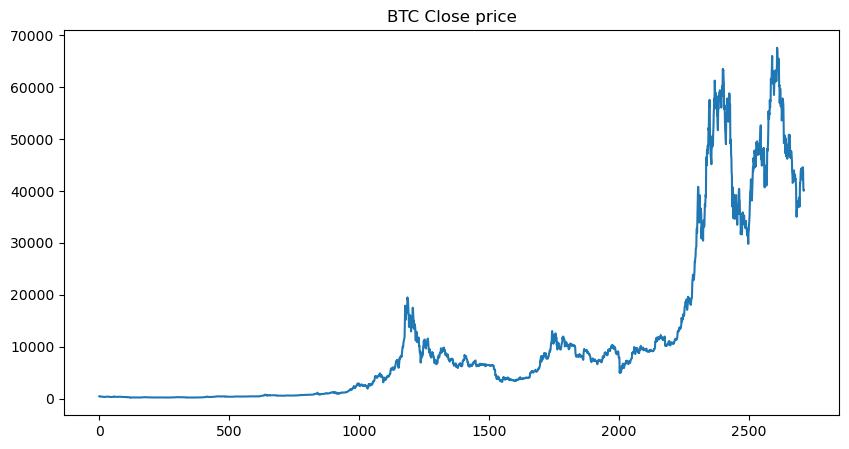

In [15]:
plt.figure(figsize=(10,5))
plt.plot(btc['Close'])

plt.title('BTC Close price')
plt.savefig('BTC Close price',dpi=300)

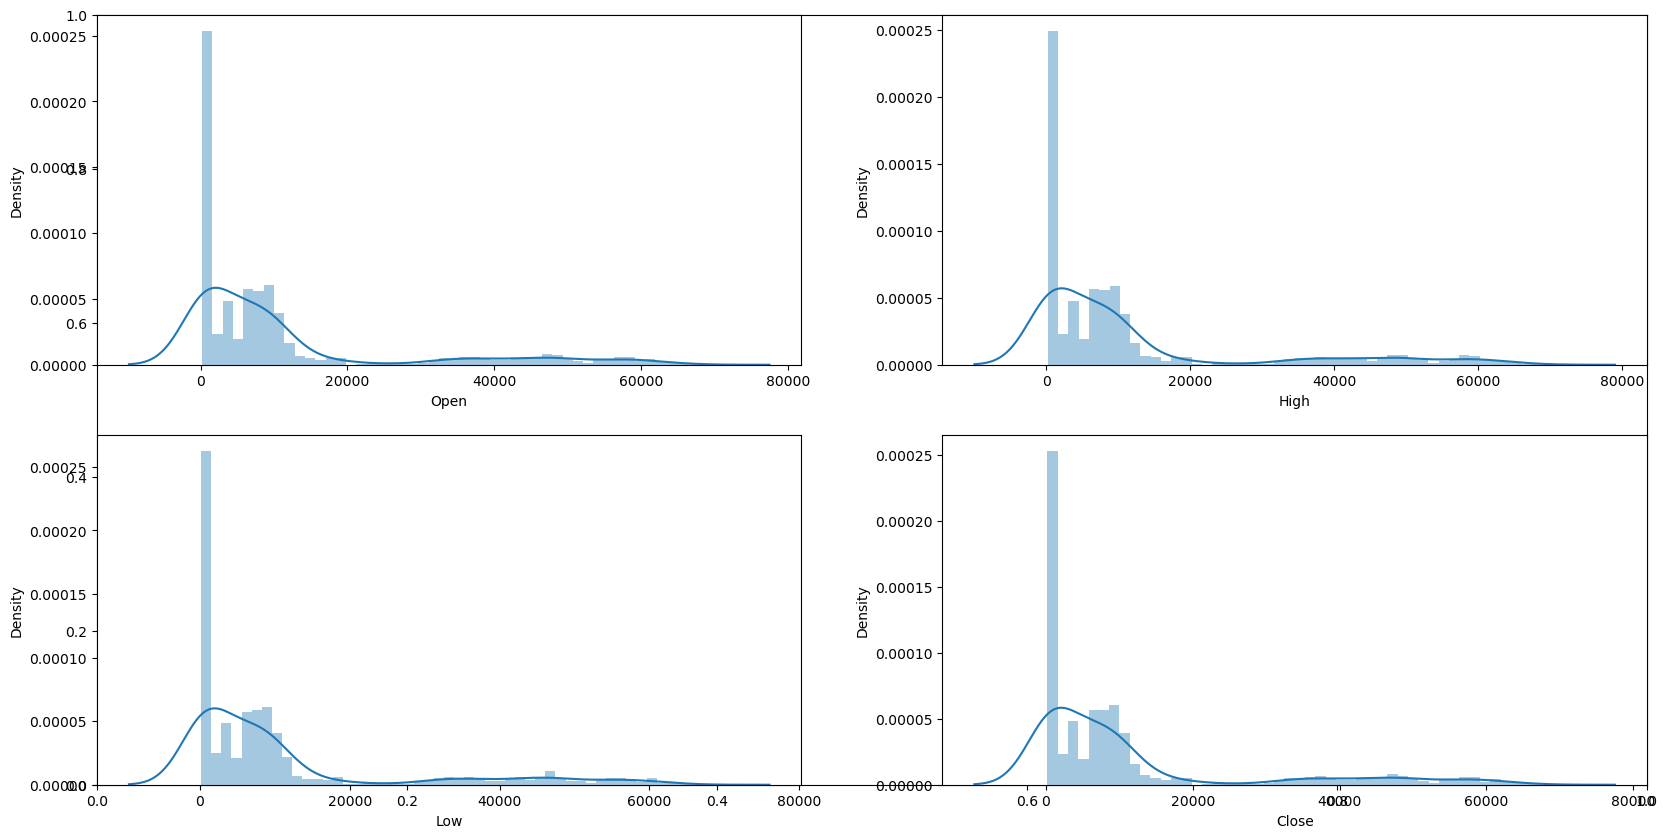

In [16]:
features=['Open','High','Low','Close']

plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
    plt.subplot(2,2,i+1)
    sns.distplot(btc[col])

plt.show
plt.savefig('Feature plot',dpi=300)

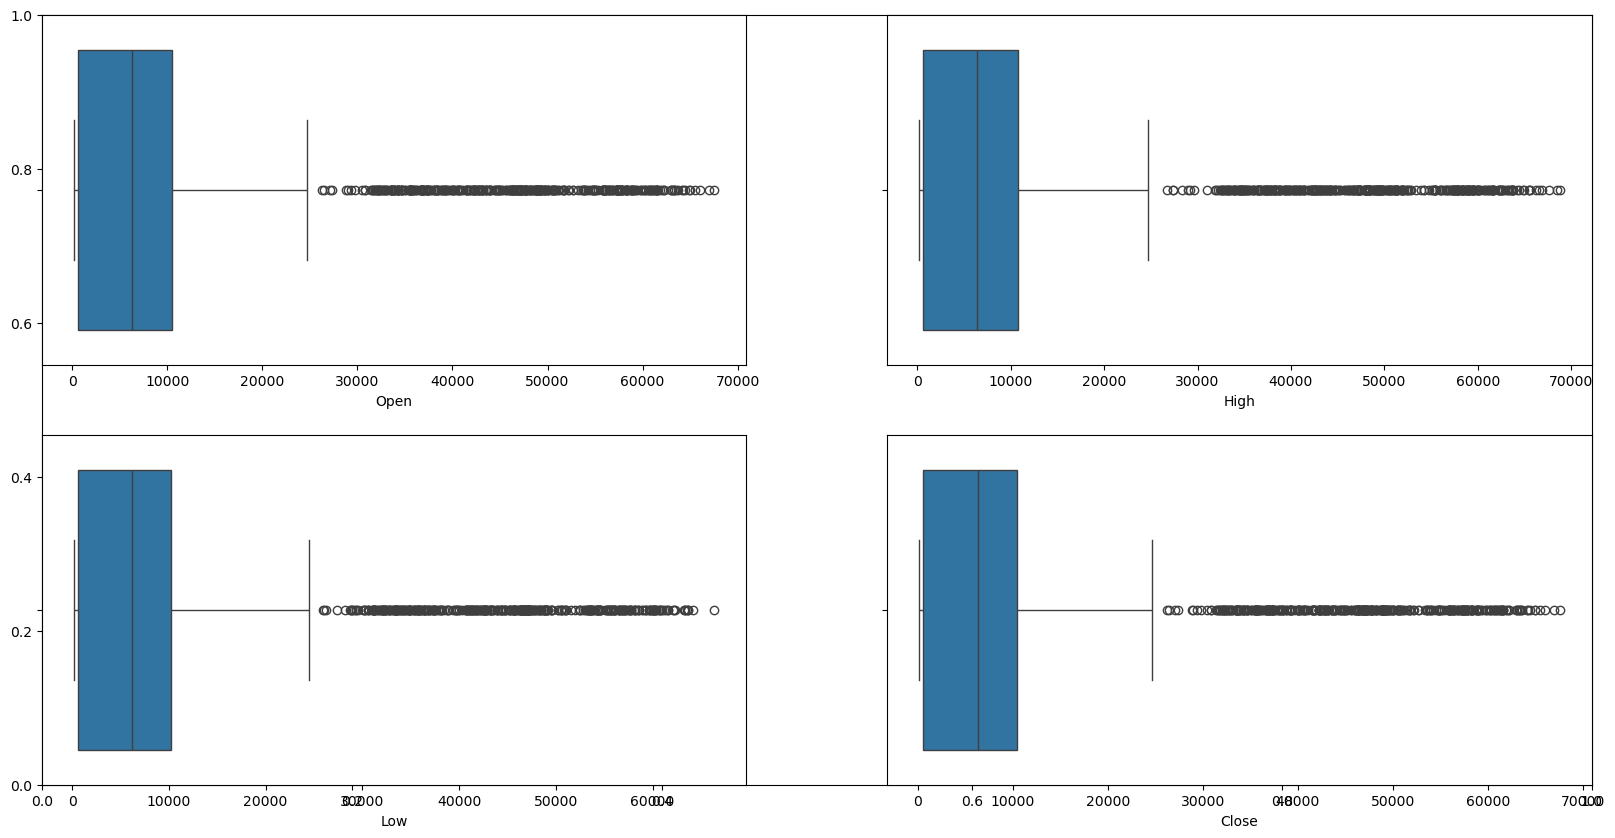

In [17]:
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
    plt.subplot(2,2,i+1)
    sns.boxplot(btc[col],orient='h')
plt.savefig('Feature boxplot',dpi=300)

In [7]:
split=btc['Date'].str.split('-', expand=True)
btc['Year']=split[0].astype('int')
btc['Month']=split[1].astype('int')
btc['day']=split[2].astype('int')
btc['Date']=pd.to_datetime(btc['Date'])
btc.head(5)
btc.info()
                             

<class 'pandas.DataFrame'>
RangeIndex: 2713 entries, 0 to 2712
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2713 non-null   datetime64[us]
 1   Open       2713 non-null   float64       
 2   High       2713 non-null   float64       
 3   Low        2713 non-null   float64       
 4   Close      2713 non-null   float64       
 5   Adj Close  2713 non-null   float64       
 6   Volume     2713 non-null   int64         
 7   Year       2713 non-null   int64         
 8   Month      2713 non-null   int64         
 9   day        2713 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(4)
memory usage: 212.1 KB


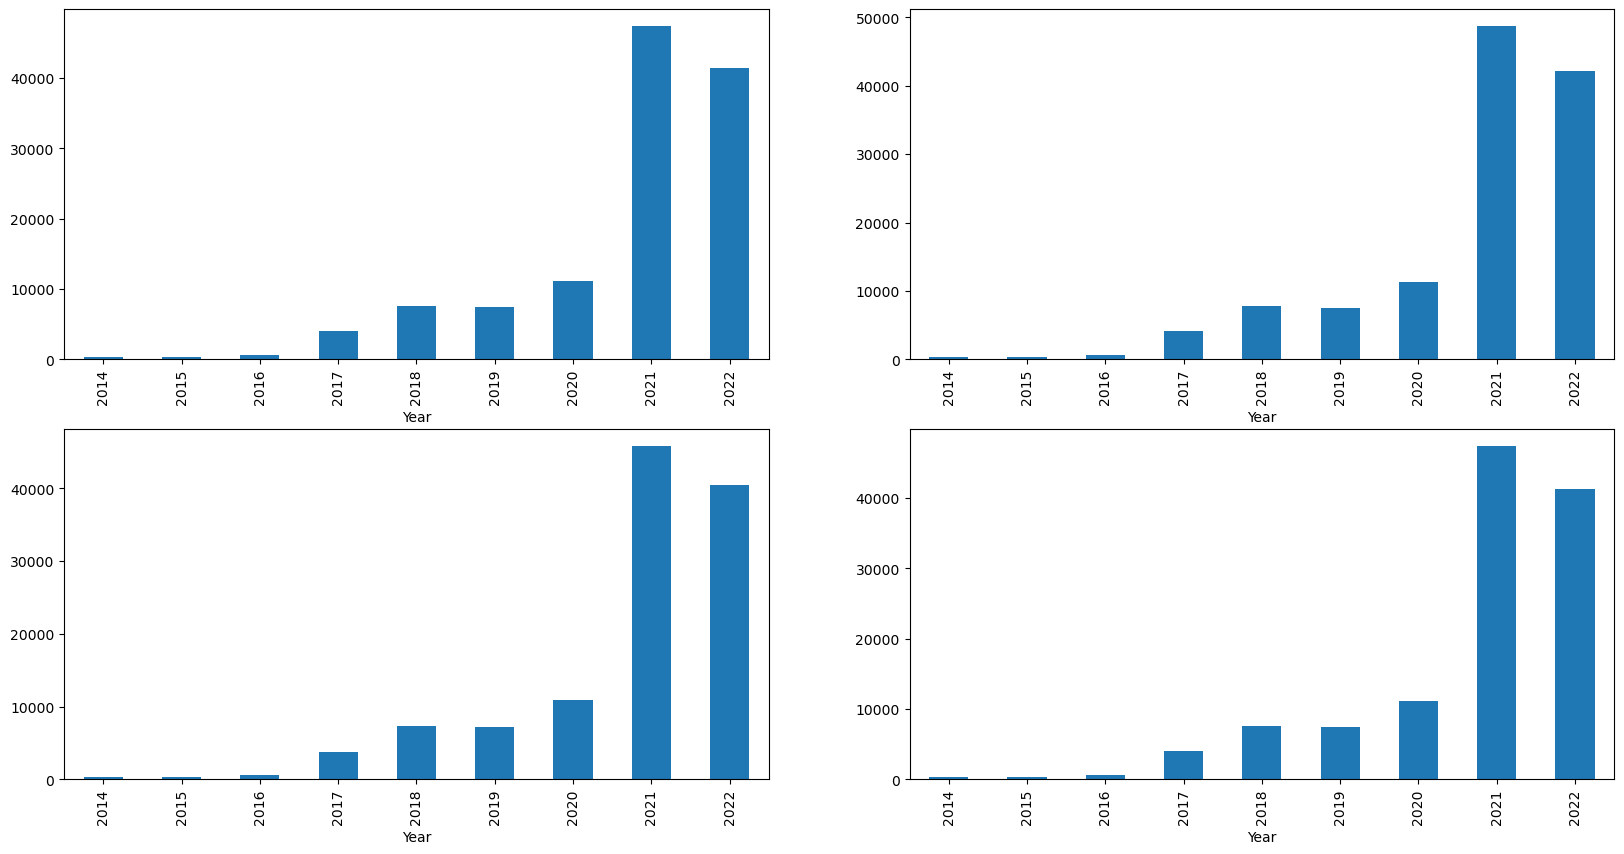

In [18]:
btc_grp=btc.groupby('Year').mean()
plt.figure(figsize=(20,10))
for i, col in enumerate(features):
    plt.subplot(2,2,1+i)
    btc_grp[col].plot(kind='bar')
plt.savefig('Feature group by year',dpi=300)


In [9]:
btc['Is Quater']=np.where(btc['Month']%3==0,1,0)
btc.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,day,Is Quater
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,2014,9,17,1
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,2014,9,18,1
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,2014,9,19,1
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,2014,9,20,1
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,2014,9,21,1


In [10]:
btc['open-close']=btc['Open']-btc['Close']
btc['high-low']=btc['High']-btc['Low']
btc['Target']=np.where(btc['Close'].shift(-1)>btc['Close'],1,0)
btc
btc['Target'].value_counts().sort_index()

Target
0    1244
1    1469
Name: count, dtype: int64

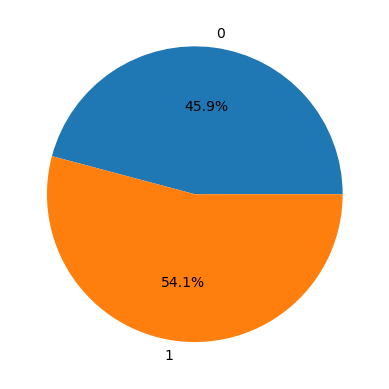

In [19]:
plt.pie(btc['Target'].value_counts().sort_values().values,labels=btc['Target'].value_counts().sort_index().index, autopct='%1.1f%%');
plt.savefig('Target Distributon',dpi=300)

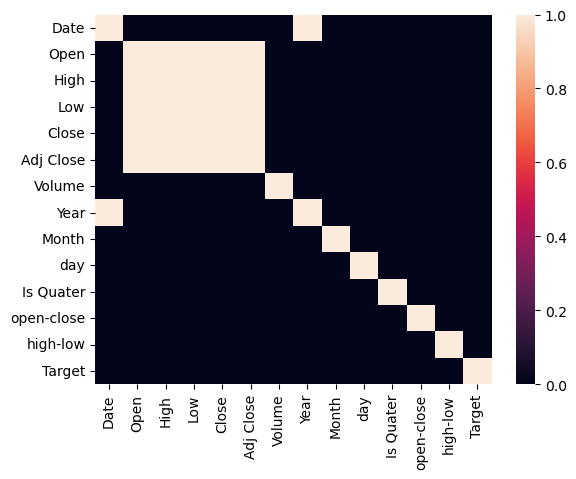

In [20]:
sns.heatmap(btc.corr()>0.9)
plt.savefig('Feature correlation',dpi=300)

In [13]:
features=btc[['open-close','high-low','Is Quater']]
target=btc['Target']



x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.2,random_state=25)
scaler=StandardScaler()
x_test=scaler.fit_transform(x_test)


In [22]:
models=[LogisticRegression(),SVC(kernel='poly',probability=True),XGBClassifier()]

for i in range(3):
    models[i].fit(x_train,y_train)
    print(f'{models[i]}:')
    print('Training Accuracy :',metrics.roc_auc_score(y_train,models[i].predict_proba(x_train)[:,1]))
    print('Validation Accuracy :',metrics.roc_auc_score(y_test,models[i].predict_proba(x_test)[:,1]))
          




LogisticRegression():
Training Accuracy : 0.5261755586442852
Validation Accuracy : 0.5210365270606234
SVC(kernel='poly', probability=True):
Training Accuracy : 0.5298920132577782
Validation Accuracy : 0.48851187061169854
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...):
Training Accuracy 

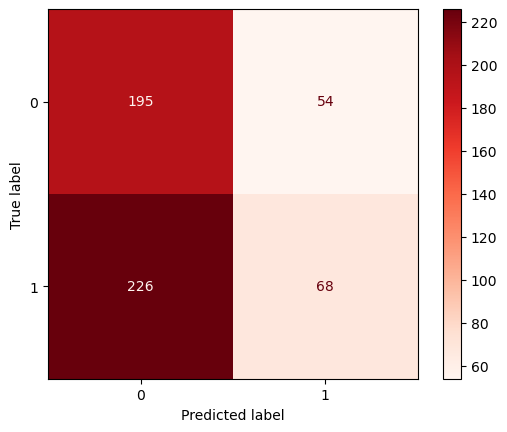

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(models[2],x_test,y_test,cmap='Reds')